# 04 — FINAL Multi-Horizon: Du bao 4 mat hang tai H = 1, 5, 10, 30, 60

> De `CONFIG['run_all_targets'] = True` va Run All mot lan. Notebook tu chay lan luot 4 target va hien bang multihorizon tong hop o o cuoi.

Theo notebook 3, nhung danh gia **nhieu horizon** de do **su phan ra tin hieu** (signal decay) khi du bao cang xa.

- **Horizons:** H ∈ {1, 5, 10, 30, 60} ngay.
- **Them dac trung mua vu:** `Sin(Date)`, `Cos(Date)` (chu ky nam, day-of-year) — bo sung cho Month/DOW sin-cos co san.
- **Mo hinh** (giong nb3): SARIMA, ARIMAX, Jump-Gated ARIMAX-CatBoost, Ridge/Linear, Logistic (huong), LightGBM, LSTM, iTransformer, GUMNet-Lite, GUMNet-Ultra, PatchTST, TFT.
- **Chi so:** MAE, RMSE, MAPE, SMAPE, R2 (one-step → multi-step roi). DL/PyTorch tu dong skip neu thieu thu vien.

> ARIMA/SARIMA dung **rolling H-step** (forecast H buoc tai moi moc, khong refit). ML/DL: target = gia mat hang dang chon tai t+H.
> Chay nang: 11 mo hinh × 5 horizon. Giam `CONFIG['horizons']` / tat `run_seq_dl`, `run_nf` de chay nhanh.

> **Jump-Gated ARIMAX-CatBoost duoc mo rong cho multi-horizon:** H1 hoi 'ngay mai co nhay gia khong'; H5/H10/H30/H60 hoi 'trong H ngay toi co bien dong lon khong'.

In [1]:
# === Setup ===
import os
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")   # repo models use Keras-2 API (TF 2.17 = Keras 3)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

TARGETS = ["MG95", "MG92", "DO 0.001%", "DO 0.05%"]

CONFIG = {
    "targets":      TARGETS,
    "target":       os.environ.get("FORECAST_TARGET", TARGETS[0]),
    "run_all_targets": True,
    "horizons":     [1, 5, 10, 30, 60],
    "train_ratio":  0.80,
    "val_ratio":    0.10,
    "exog_cols":    ["WTI", "USD_Index", "GPR", "BRT DTD", "Brent_EU_Daily"],
    "seasonal":     5,
    "seq_len_by_h": {1: 30, 5: 30, 10: 45, 30: 60, 60: 90},
    "dl_epochs":    30,      # epochs cho LSTM/iTransformer/GUMNet
    "nf_steps":     300,     # max_steps cho PatchTST/TFT
    "run_seq_dl":   True,    # LSTM/iTransformer/GUMNet (can tensorflow)
    "run_nf":       True,    # PatchTST/TFT (can neuralforecast)
    "run_jump_gated": True, # Jump-Gated ARIMAX-CatBoost multi-horizon
    "tune_lgbm":    False,
}
if CONFIG["target"] not in TARGETS:
    raise ValueError(f"Target khong hop le: {CONFIG['target']}. Chon mot trong {TARGETS}")
print("ROOT =", ROOT)
print("Target:", CONFIG["target"], "| Horizons:", CONFIG["horizons"])

ROOT = e:\PCDOC\xangdau\XANG_DAU_FORECAST\XANG_DAU_FORECAST
Target: MG95 | Horizons: [1, 5, 10, 30, 60]


## 1. Load du lieu + Sin(Date)/Cos(Date) + (tuy chon) News

In [2]:
from src.data_loader import load_and_engineer
TARGET = CONFIG["target"]
TARGET_SLUG = TARGET.replace("%", "pct").replace(" ", "_").replace(".", "_")
TARGET_RESULT_DIR = ROOT / "results" / "by_target" / TARGET_SLUG
TARGET_CHART_DIR = ROOT / "results" / "charts" / TARGET_SLUG
TARGET_RESULT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_CHART_DIR.mkdir(parents=True, exist_ok=True)
df = load_and_engineer(target_col=TARGET)

# --- Sin(Date) & Cos(Date): chu ky mua vu theo nam (day-of-year) ---
doy = df.index.dayofyear.values
df["DOY_sin"] = np.sin(2 * np.pi * doy / 365.25)
df["DOY_cos"] = np.cos(2 * np.pi * doy / 365.25)
print("Added Sin(Date)/Cos(Date): DOY_sin, DOY_cos")

# --- News (optional) ---
news_path = ROOT / "news-crawler" / "data" / "daily_features.csv"
news_cols = []
if news_path.exists():
    news = pd.read_csv(news_path, parse_dates=["date"]).set_index("date")
    news = news[~news.index.duplicated(keep="last")].sort_index()
    df = df.join(news, how="left"); news_cols = list(news.columns)
    df[news_cols] = df[news_cols].fillna(0.0)
    print(f"News joined: +{len(news_cols)} cot")
else:
    print("Khong co daily_features.csv -> chay khong co news.")

feature_cols = [c for c in df.columns if c != TARGET]
print("df:", df.shape, "| features:", len(feature_cols), "| range", df.index.min().date(), "->", df.index.max().date())

Added Sin(Date)/Cos(Date): DOY_sin, DOY_cos
Khong co daily_features.csv -> chay khong co news.
df: (4619, 54) | features: 53 | range 2008-06-12 -> 2026-05-08


## 2. Chi so + cac ham chuan bi du lieu (tabular & sequence)

In [3]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score)
from sklearn.preprocessing import RobustScaler

def reg_metrics(y_true, y_pred, name, H):
    yt = np.asarray(y_true, float); yp = np.asarray(y_pred, float)
    mae  = mean_absolute_error(yt, yp)
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    mape = float(np.mean(np.abs((yt - yp) / (np.abs(yt) + 1e-8))) * 100)
    smape = float(np.mean(2.0 * np.abs(yp - yt) / (np.abs(yt) + np.abs(yp) + 1e-8)) * 100)
    return {"Model": name, "Horizon": H, "MAE": round(mae,4), "RMSE": round(rmse,4),
            "MAPE(%)": round(mape,4), "SMAPE(%)": round(smape,4), "R2": round(float(r2_score(yt,yp)),4)}

def prep_tabular(H):
    w = df.copy(); w["__y"] = w[TARGET].shift(-H); w = w.dropna(subset=["__y"])
    n = len(w); ntr = int(n*CONFIG["train_ratio"]); nvl = int(n*CONFIG["val_ratio"])
    tr, vl, te = w.iloc[:ntr], w.iloc[ntr:ntr+nvl], w.iloc[ntr+nvl:]
    sx = RobustScaler().fit(tr[feature_cols])
    Xtr, Xvl, Xte = sx.transform(tr[feature_cols]), sx.transform(vl[feature_cols]), sx.transform(te[feature_cols])
    out = dict(Xtr=Xtr, Xvl=Xvl, Xte=Xte,
               ytr=tr["__y"].values, yvl=vl["__y"].values, yte=te["__y"].values,
               dir_tr=(tr["__y"].values > tr[TARGET].values).astype(int),
               dir_te=(te["__y"].values > te[TARGET].values).astype(int),
               test_dates=te.index)
    return out

def prep_sequences(H):
    from src.data_loader import make_windows
    SEQ = CONFIG["seq_len_by_h"][H]
    n_df = len(df); ntr = int(n_df*CONFIG["train_ratio"])
    sxq = RobustScaler().fit(df[feature_cols].iloc[:ntr])
    syq = RobustScaler().fit(df[[TARGET]].iloc[:ntr])
    Xall = sxq.transform(df[feature_cols].values)
    yall = syq.transform(df[[TARGET]].values).flatten()
    Xw, yw = make_windows(Xall, yall, time_steps=SEQ, horizon=H)
    nW = len(Xw); a = int(nW*0.8); b = int(nW*0.1)
    return dict(Xw_tr=Xw[:a], Xw_vl=Xw[a:a+b], Xw_te=Xw[a+b:],
                yw_tr=yw[:a], yw_vl=yw[a:a+b], yw_te=yw[a+b:],
                scaler_y=syq, SEQ=SEQ, N_FEAT=len(feature_cols))

print("Helpers ready.")

Helpers ready.


## 3. Mo hinh thong ke — rolling H-step ARIMAX & SARIMA

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
exog_all = [c for c in CONFIG["exog_cols"] if c in df.columns]

def _arima_rolling(y, exog, split, order, seas, H, maxiter=50):
    # Fit tren [0:split], forecast H-step tai moi moc (append, khong refit).
    res = SARIMAX(y[:split], exog=None if exog is None else exog[:split],
                  order=order, seasonal_order=seas,
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=maxiter)
    cur = res; N = len(y); o = split - 1; idxs, preds = [], []
    while o + H <= N - 1:
        if exog is None: fc = cur.forecast(steps=H)
        else: fc = cur.forecast(steps=H, exog=exog[o+1:o+1+H])
        preds.append(float(np.asarray(fc)[-1])); idxs.append(o + H)
        if exog is None: cur = cur.extend(y[o+1:o+2])            # extend = O(1), khong refit
        else: cur = cur.extend(y[o+1:o+2], exog=exog[o+1:o+2])
        o += 1
    return np.array(idxs), np.array(preds)

def fit_arimax(H):
    y = df[TARGET].reset_index(drop=True).astype(float)
    ex = df[exog_all].reset_index(drop=True).astype(float)
    split = int(len(y) * 0.9)
    idx, pred = _arima_rolling(y, ex, split, (2,1,2), (0,0,0,0), H)
    return y.values[idx], pred

def fit_sarima(H):
    y = df[TARGET].reset_index(drop=True).astype(float)
    split = int(len(y) * 0.9)
    idx, pred = _arima_rolling(y, None, split, (1,1,1), (1,0,1,CONFIG["seasonal"]), H)
    return y.values[idx], pred

print("ARIMA helpers ready.")

ARIMA helpers ready.


## 4. Jump-Gated ARIMAX-CatBoost multi-horizon

Cung mot framework cho tat ca horizon: ARIMAX du bao H-step, CatBoost sua sai so, va cong phu nhan dien bien dong lon trong khoang H ngay.

In [5]:
from src.models.jump_gated_arimax_catboost import (
    JumpGatedConfig,
    run_jump_gated_arimax_catboost_horizon,
)

jump_details = {}

def fit_jump_gated_arimax_catboost(H):
    cfg = JumpGatedConfig(
        target=TARGET,
        horizon=H,
        train_ratio=CONFIG["train_ratio"],
        val_ratio=CONFIG["val_ratio"],
        exog_cols=CONFIG["exog_cols"],
        arimax_order=(2, 1, 2),
        # Giu it bien the hon de notebook 04 khong qua nang.
        jump_thresholds=[1.5, 2, 2.5, 3, 4, 5],
        soft_gammas=[1, 2],
        hard_cutoffs=[0.2, 0.35, 0.5],
    )
    out = run_jump_gated_arimax_catboost_horizon(
        load_and_engineer(target_col=TARGET),
        horizon=H,
        root=ROOT,
        config=cfg,
        exact_h1=True,
        progress=True,
    )
    jump_details[H] = out
    return out["y_test"], out["pred_jump_gated"]

print("Jump-Gated ARIMAX-CatBoost multi-horizon helper ready.")

Jump-Gated ARIMAX-CatBoost multi-horizon helper ready.


## 5. ML models - Ridge, LightGBM, Logistic (huong)

In [6]:
from sklearn.linear_model import Ridge, LogisticRegression
import lightgbm as lgb

def fit_ridge(d):
    m = Ridge(alpha=1.0).fit(d["Xtr"], d["ytr"]); return d["yte"], m.predict(d["Xte"])

def fit_lgbm(d):
    if CONFIG["tune_lgbm"]:
        from src.models.baseline_lgbm import tune_lgbm, train_lgbm
        bp = tune_lgbm(d["Xtr"], d["ytr"], d["Xvl"], d["yvl"], n_trials=30)["best_params"]
        m = train_lgbm(d["Xtr"], d["ytr"], d["Xvl"], d["yvl"], bp)
    else:
        m = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, max_depth=7, num_leaves=63,
                              subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
                              random_state=42, n_jobs=-1, verbose=-1)
        m.fit(d["Xtr"], d["ytr"], eval_set=[(d["Xvl"], d["yvl"])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    return d["yte"], m.predict(d["Xte"])

def fit_logistic(d, H):
    clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(d["Xtr"], d["dir_tr"])
    p = clf.predict(d["Xte"])
    return {"Model": "LogisticRegression (huong)", "Horizon": H,
            "Accuracy": round(float(accuracy_score(d["dir_te"], p)),4),
            "F1": round(float(f1_score(d["dir_te"], p, zero_division=0)),4),
            "BaseUpRate": round(float(d["dir_te"].mean()),4)}
print("ML helpers ready.")

ML helpers ready.


## 6. Deep models - LSTM, iTransformer, GUMNet-Lite/Ultra (Keras); PatchTST/TFT (neuralforecast)

In [7]:
def _seq_eval(model, s):
    pred = s["scaler_y"].inverse_transform(np.asarray(model.predict(s["Xw_te"], verbose=0)).reshape(-1,1)).flatten()
    ytru = s["scaler_y"].inverse_transform(s["yw_te"].reshape(-1,1)).flatten()
    return ytru, pred

def fit_lstm(s, H):
    import tensorflow as tf
    from tensorflow.keras import layers, Model
    tf.random.set_seed(42); tf.keras.backend.clear_session()
    inp = layers.Input((s["SEQ"], s["N_FEAT"]))
    x = layers.LSTM(64, return_sequences=True)(inp); x = layers.Dropout(0.2)(x)
    x = layers.LSTM(32)(x); x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1)(x)
    m = Model(inp, out); m.compile(optimizer="adam", loss="mse")
    es = tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)
    m.fit(s["Xw_tr"], s["yw_tr"], validation_data=(s["Xw_vl"], s["yw_vl"]),
          epochs=CONFIG["dl_epochs"], batch_size=64, callbacks=[es], verbose=0)
    return _seq_eval(m, s)

def fit_itransformer(s, H):
    from src.models.hybrid_sota import train_itransformer
    m, _ = train_itransformer(s["Xw_tr"], s["yw_tr"], s["Xw_vl"], s["yw_vl"],
                              time_steps=s["SEQ"], n_features=s["N_FEAT"], horizon=H,
                              epochs=CONFIG["dl_epochs"], batch_size=64)
    return _seq_eval(m, s)

def fit_gumnet_lite(s, H):
    from src.models.hybrid_sota import train_gumnet_lite
    m, _ = train_gumnet_lite(s["Xw_tr"], s["yw_tr"], s["Xw_vl"], s["yw_vl"],
                             time_steps=s["SEQ"], n_features=s["N_FEAT"], horizon=H,
                             epochs=CONFIG["dl_epochs"], batch_size=64)
    return _seq_eval(m, s)

def fit_gumnet_ultra(s, H):
    from src.models.hybrid_sota import train_gumnet_ultra
    m, _ = train_gumnet_ultra(s["Xw_tr"], s["yw_tr"], s["Xw_vl"], s["yw_vl"],
                              time_steps=s["SEQ"], n_features=s["N_FEAT"], horizon=H,
                              epochs=CONFIG["dl_epochs"], batch_size=64)
    return _seq_eval(m, s)

def fit_neuralforecast(H):
    from neuralforecast import NeuralForecast
    from neuralforecast.models import PatchTST, TFT
    nf_exog = [c for c in CONFIG["exog_cols"] if c in df.columns]
    base = df[[TARGET] + nf_exog].copy().asfreq("B").ffill()
    long = base.reset_index(); long.columns = ["ds"] + [TARGET] + nf_exog
    long["unique_id"] = TARGET; long["y"] = long[TARGET]
    long = long[["unique_id", "ds", "y"] + nf_exog]
    n_win = min(200, max(20, int(len(df) * 0.1)))
    common = dict(h=H, input_size=CONFIG["seq_len_by_h"][H], max_steps=CONFIG["nf_steps"],
                  scaler_type="robust", hist_exog_list=nf_exog, enable_progress_bar=False)
    nf = NeuralForecast(models=[PatchTST(**common), TFT(**common)], freq="B")
    cv = nf.cross_validation(df=long, n_windows=n_win, step_size=1)
    res = {}
    for mname in ["PatchTST", "TFT"]:
        if mname in cv.columns:
            sub = cv.dropna(subset=[mname]); res[mname] = (sub["y"].values, sub[mname].values)
    return res
print("DL helpers ready.")

DL helpers ready.


## 7. Driver - chay tat ca mo hinh tren tat ca horizon

In [8]:
import time
results = []      # regression rows (co Horizon)
clf_results = []  # logistic rows

for H in CONFIG["horizons"]:
    t0 = time.time(); print("="*70); print(f"HORIZON H = {H}"); print("="*70)
    d = prep_tabular(H)

    # --- statistical ---
    for name, fn in [("ARIMAX", fit_arimax), ("SARIMA", fit_sarima)]:
        try:
            yt, yp = fn(H); results.append(reg_metrics(yt, yp, name, H)); print(" ", results[-1])
        except Exception as e:
            print(f"  {name} skipped:", repr(e))

    # --- hybrid moi: ARIMAX-CatBoost co cong nhan dien bien dong lon ---
    if CONFIG.get("run_jump_gated", True):
        try:
            yt, yp = fit_jump_gated_arimax_catboost(H)
            results.append(reg_metrics(yt, yp, "Jump-Gated ARIMAX-CatBoost", H))
            print(" ", results[-1])
        except Exception as e:
            print("  Jump-Gated ARIMAX-CatBoost skipped:", repr(e))

    # --- linear / tree ---
    for name, fn in [("Ridge (Linear)", fit_ridge), ("LightGBM", fit_lgbm)]:
        try:
            yt, yp = fn(d); results.append(reg_metrics(yt, yp, name, H)); print(" ", results[-1])
        except Exception as e:
            print(f"  {name} skipped:", repr(e))

    # # --- logistic direction ---
    # try:
    #     clf_results.append(fit_logistic(d, H)); print(" ", clf_results[-1])
    # except Exception as e:
    #     print("  Logistic skipped:", repr(e))

    # --- sequence DL (Keras) ---
    if CONFIG["run_seq_dl"]:
        try:
            s = prep_sequences(H)
            for name, fn in [("LSTM", fit_lstm), ("iTransformer", fit_itransformer),
                             ("GUMNet-Lite", fit_gumnet_lite), ("GUMNet-Ultra", fit_gumnet_ultra)]:
                try:
                    yt, yp = fn(s, H); results.append(reg_metrics(yt, yp, name, H)); print(" ", results[-1])
                except Exception as e:
                    print(f"  {name} skipped:", repr(e))
        except Exception as e:
            print("  Sequence prep skipped:", repr(e))

    # --- PatchTST / TFT (neuralforecast) ---
    if CONFIG["run_nf"]:
        try:
            for mname, (yt, yp) in fit_neuralforecast(H).items():
                results.append(reg_metrics(yt, yp, mname, H)); print(" ", results[-1])
        except Exception as e:
            print("  PatchTST/TFT skipped:", repr(e))

    print(f"  [H={H}] done in {time.time()-t0:.1f}s")

print("\nALL HORIZONS DONE. rows:", len(results))

HORIZON H = 1


c:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  {'Model': 'ARIMAX', 'Horizon': 1, 'MAE': 1.4434, 'RMSE': 2.7534, 'MAPE(%)': 1.4692, 'SMAPE(%)': 1.4705, 'R2': 0.9762}
  {'Model': 'SARIMA', 'Horizon': 1, 'MAE': 1.5108, 'RMSE': 3.0496, 'MAPE(%)': 1.554, 'SMAPE(%)': 1.5528, 'R2': 0.9709}


c:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


OOF fold 1: 2017-04-25 -> 2018-10-03 | MAE=0.7159


...

H=60 OOF fold 3: 2020-04-20 -> 2021-09-22 | MAE=6.2441
H=60 OOF fold 4: 2021-09-23 -> 2023-02-24 | MAE=13.7028


c:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


H=60 OOF fold 5: 2023-02-27 -> 2024-08-01 | MAE=6.3079
H=60 Jump-Gated ARIMAX-CatBoost MAPE=7.3011% | MAE=7.5936
  {'Model': 'Jump-Gated ARIMAX-CatBoost', 'Horizon': 60, 'MAE': 7.5936, 'RMSE': 14.1526, 'MAPE(%)': 7.3011, 'SMAPE(%)': 7.7142, 'R2': 0.3781}
  {'Model': 'Ridge (Linear)', 'Horizon': 60, 'MAE': 9.4078, 'RMSE': 18.1694, 'MAPE(%)': 8.789, 'SMAPE(%)': 9.7647, 'R2': -0.025}
  {'Model': 'LightGBM', 'Horizon': 60, 'MAE': 11.9407, 'RMSE': 20.3057, 'MAPE(%)': 11.8971, 'SMAPE(%)': 12.4921, 'R2': -0.2802}
  {'Model': 'LSTM', 'Horizon': 60, 'MAE': 20.8748, 'RMSE': 32.707, 'MAPE(%)': 20.9533, 'SMAPE(%)': 25.6553, 'R2': -2.2511}
Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1.1675 - mae: 0.3494 - val_loss: 1.3977 - val_mae: 0.4248 - learning_rate: 5.0000e-04
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.6892 - mae: 0.2158 - val_loss: 1.2530 - val_mae: 0.3853 - learning_rate: 5.0000e-04
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.6557 - mae: 0.

Seed set to 1


  {'Model': 'GUMNet-Ultra', 'Horizon': 60, 'MAE': 9.6032, 'RMSE': 20.5051, 'MAPE(%)': 8.65, 'SMAPE(%)': 9.8914, 'R2': -0.2778}
  PatchTST/TFT skipped: Exception('PatchTST does not support historical exogenous variables.')
  [H=60] done in 142.5s

ALL HORIZONS DONE. rows: 45


## 8. Ket qua - bang + signal decay theo horizon

In [9]:
import matplotlib.pyplot as plt

res_df = pd.DataFrame(results)
res_df.insert(0, "Target", TARGET)
target_csv = TARGET_RESULT_DIR / "multihorizon_results.csv"
res_df.to_csv(target_csv, index=False)

combined_path = ROOT / "results" / "multihorizon_results_all_targets.csv"
if combined_path.exists():
    previous_rows = pd.read_csv(combined_path)
    previous_rows = previous_rows[previous_rows["Target"] != TARGET]
    combined_rows = pd.concat([previous_rows, res_df], ignore_index=True)
else:
    combined_rows = res_df.copy()
combined_rows.to_csv(combined_path, index=False)

if TARGET == "MG95":
    res_df.drop(columns=["Target"]).to_csv(ROOT / "results" / "multihorizon_results.csv", index=False)

print("=== Full results (long) ===")
display(res_df)

# Pivot: R2 va MAPE theo (Model x Horizon)
for met in ["R2", "MAPE(%)", "MAE", "SMAPE(%)"]:
    piv = res_df.pivot_table(index="Model", columns="Horizon", values=met)
    print(f"\n--- {met} (Model x Horizon) ---"); display(piv)

print(f"Saved -> {target_csv}")
print(f"Updated -> {combined_path}")

# if clf_results:
#     print("\n=== Logistic (huong) theo horizon ===")
#     display(pd.DataFrame(clf_results).set_index(["Model","Horizon"]))

=== Full results (long) ===


,Target,Model,Horizon,MAE,RMSE,MAPE(%),SMAPE(%),R2
0,MG95,ARIMAX,1,1.4434,2.7534,1.4692,1.4705,0.9762
1,MG95,SARIMA,1,1.5108,3.0496,1.5540,1.5528,0.9709
2,MG95,Jump-Gated ARIMAX-CatBoost,1,1.2450,2.6052,1.2462,1.2464,0.9787
3,MG95,Ridge (Linear),1,1.4552,2.8922,1.4420,1.4538,0.9737
4,MG95,LightGBM,1,1.9879,3.7201,2.0259,2.0578,0.9566
5,MG95,LSTM,1,3.8860,7.1657,3.9757,4.0581,0.8397
6,MG95,iTransformer,1,5.0306,9.8141,4.8283,4.9904,0.6992
7,MG95,GUMNet-Lite,1,6.3383,11.9734,6.1336,6.0046,0.5523
8,MG95,GUMNet-Ultra,1,3.5850,6.6907,3.5227,3.5406,0.8602
9,MG95,ARIMAX,5,2.8081,5.4337,2.8274,2.8561,0.9082



--- R2 (Model x Horizon) ---


Horizon,1,5,10,30,60
Model,,,,,
ARIMAX,0.9762,0.9082,0.8097,0.4765,0.4127
GUMNet-Lite,0.5523,0.5453,0.2457,-0.3953,-0.5831
GUMNet-Ultra,0.8602,0.8096,0.5507,0.1331,-0.2778
Jump-Gated ARIMAX-CatBoost,0.9787,0.9098,0.8141,0.5351,0.3781
LSTM,0.8397,0.6080,0.4729,-0.1037,-2.2511
LightGBM,0.9566,0.8654,0.4936,0.0726,-0.2802
Ridge (Linear),0.9737,0.9033,0.7006,-0.3160,-0.0250
SARIMA,0.9709,0.8518,0.6771,0.0272,-0.3820
iTransformer,0.6992,0.5286,0.2734,-0.5889,-1.9131



--- MAPE(%) (Model x Horizon) ---


...


--- MAE (Model x Horizon) ---


Horizon,1,5,10,30,60
Model,,,,,
ARIMAX,1.4434,2.8081,3.7943,6.4852,7.5360
GUMNet-Lite,6.3383,7.2558,7.9380,12.2672,11.9188
GUMNet-Ultra,3.5850,4.5001,5.8498,9.1914,9.6032
Jump-Gated ARIMAX-CatBoost,1.2450,2.7446,3.7475,6.2798,7.5936
LSTM,3.8860,5.5237,6.4388,9.9686,20.8748
LightGBM,1.9879,3.7367,6.2255,9.1543,11.9407
Ridge (Linear),1.4552,3.1833,4.8707,10.2850,9.4078
SARIMA,1.5108,3.7698,4.8785,8.5796,10.9924
iTransformer,5.0306,5.9924,7.8586,15.2446,18.3499



--- SMAPE(%) (Model x Horizon) ---


Horizon,1,5,10,30,60
Model,,,,,
ARIMAX,1.4705,2.8561,3.8498,6.4597,7.5313
GUMNet-Lite,6.0046,7.4941,8.1274,12.9744,12.6355
GUMNet-Ultra,3.5406,4.7392,6.1056,9.5560,9.8914
Jump-Gated ARIMAX-CatBoost,1.2464,2.7923,3.7936,6.2772,7.7142
LSTM,4.0581,5.7781,6.7708,10.5379,25.6553
LightGBM,2.0578,3.9863,6.2768,9.4510,12.4921
Ridge (Linear),1.4538,3.3294,4.8352,9.6370,9.7647
SARIMA,1.5528,3.9068,5.0210,8.8458,11.3846
iTransformer,4.9904,5.9842,7.9680,16.2328,20.8813


Saved -> e:\PCDOC\xangdau\XANG_DAU_FORECAST\XANG_DAU_FORECAST\results\by_target\MG95\multihorizon_results.csv
Updated -> e:\PCDOC\xangdau\XANG_DAU_FORECAST\XANG_DAU_FORECAST\results\multihorizon_results_all_targets.csv


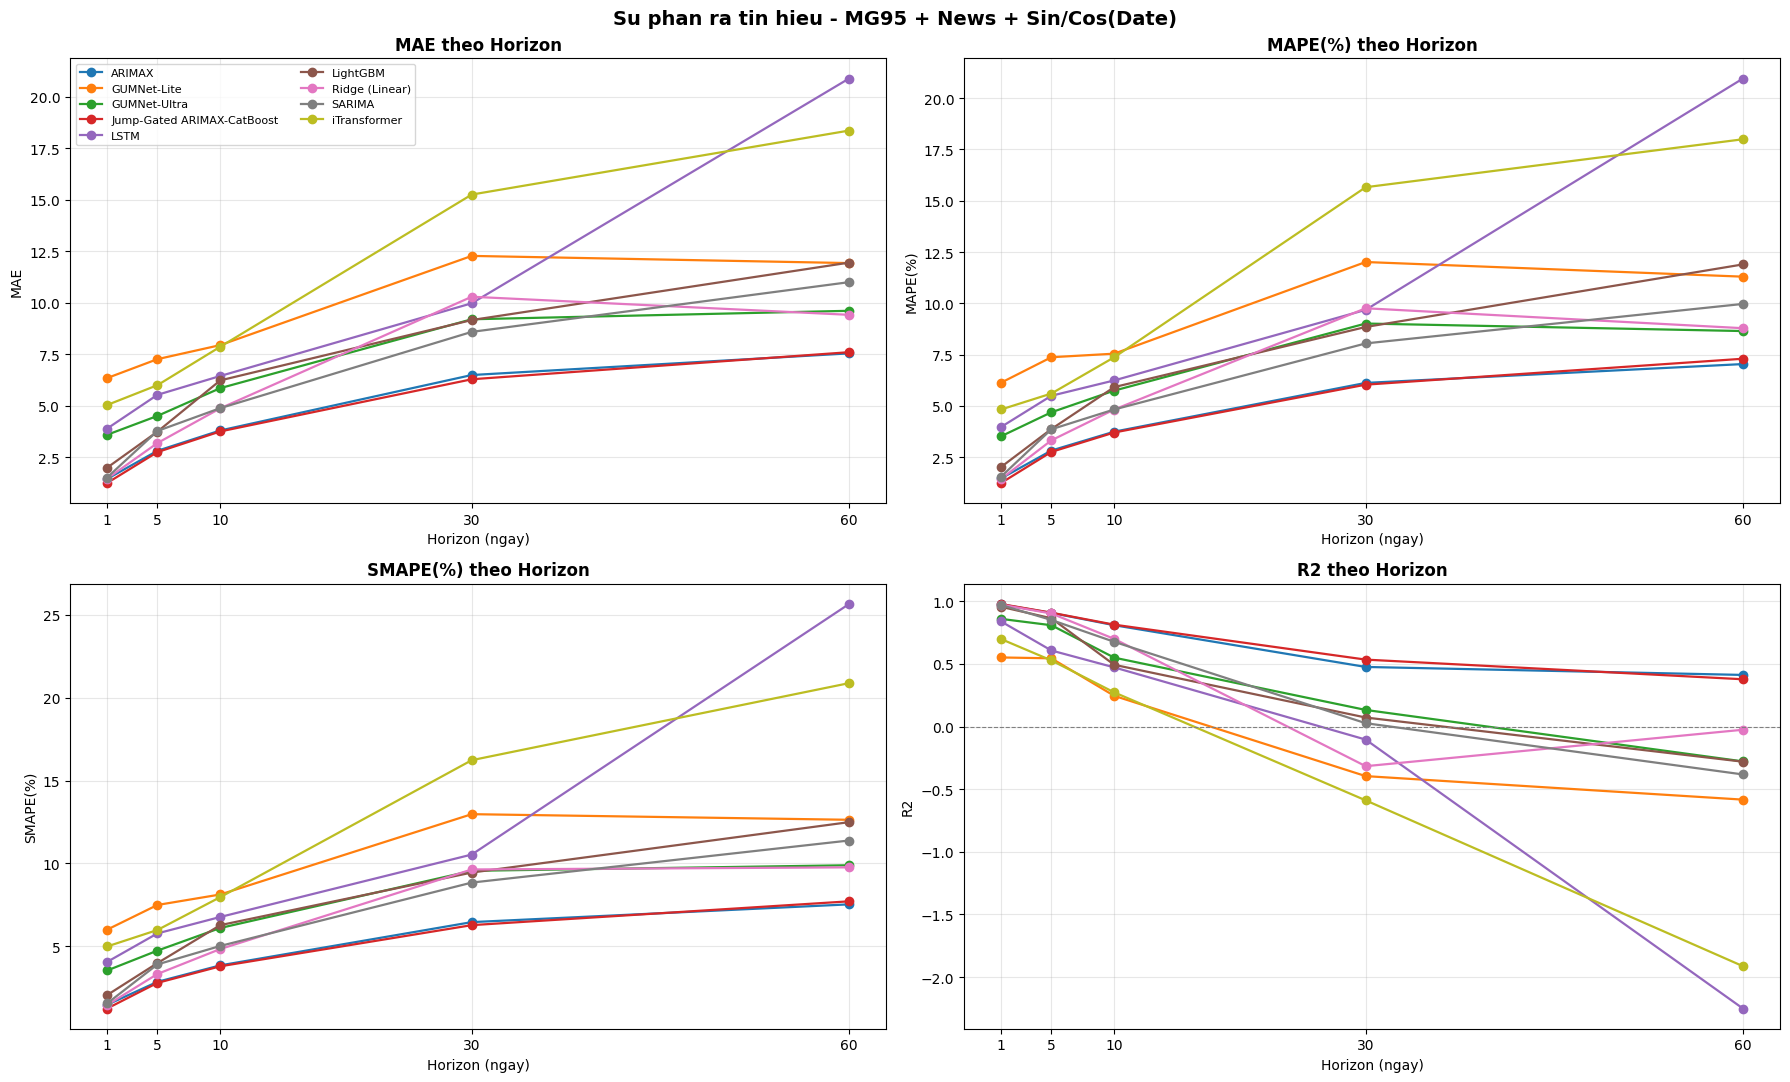

Saved chart -> e:\PCDOC\xangdau\XANG_DAU_FORECAST\XANG_DAU_FORECAST\results\charts\MG95\signal_decay.png


In [10]:
# Signal-decay: metric vs horizon, moi mo hinh 1 duong
mets = ["MAE", "MAPE(%)", "SMAPE(%)", "R2"]
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
for ax, met in zip(axes.ravel(), mets):
    piv = res_df.pivot_table(index="Horizon", columns="Model", values=met)
    for col in piv.columns:
        ax.plot(piv.index, piv[col], marker="o", lw=1.6, label=col)
    ax.set_title(met + " theo Horizon", fontweight="bold")
    ax.set_xlabel("Horizon (ngay)"); ax.set_ylabel(met)
    ax.set_xticks(CONFIG["horizons"]); ax.grid(alpha=0.3)
    if met == "R2": ax.axhline(0, color="grey", lw=0.8, ls="--")
axes.ravel()[0].legend(fontsize=8, ncol=2, loc="upper left")
plt.suptitle(f"Su phan ra tin hieu - {TARGET} + News + Sin/Cos(Date)", fontsize=14, fontweight="bold")
plt.tight_layout()
chart_path = TARGET_CHART_DIR / "signal_decay.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
if TARGET == "MG95":
    plt.savefig(ROOT / "results" / "charts" / "signal_decay.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart -> {chart_path}")

## 9. Ghi chu

- **Signal decay:** do chinh xac giam khi H tang (R2 giam, MAPE/MAE tang) — bang & bieu do o tren dinh luong dieu nay cho tung mo hinh.
- **Sin(Date)/Cos(Date):** `DOY_sin/cos` (chu ky nam) bo sung mua vu; co the giup nhat o H lon (30/60).
- ARIMA/SARIMA: rolling H-step (append, khong refit) — nhanh va cong bang.
- DL Keras + PatchTST/TFT skip neu thieu thu vien; cai xong chay lai. Giam `CONFIG['horizons']` hoac tat `run_seq_dl`/`run_nf` neu muon nhanh.
- Ket qua: `results/multihorizon_results.csv`, `results/charts/signal_decay.png`.

In [11]:
# Chay cac target con lai bang kernel phu, khong tao them file notebook.
is_batch_child = os.environ.get("FORECAST_BATCH_CHILD") == "1"
if CONFIG.get("run_all_targets", False) and not is_batch_child:
    from src.notebook_batch_runner import run_notebook_targets

    remaining_targets = [t for t in CONFIG["targets"] if t != TARGET]
    run_notebook_targets(
        ROOT / "notebooks" / "04_multihorizon.ipynb",
        remaining_targets,
        timeout=None,
    )

    all_results_path = ROOT / "results" / "multihorizon_results_all_targets.csv"
    all_results = pd.read_csv(all_results_path)
    target_order = {name: pos for pos, name in enumerate(CONFIG["targets"])}
    all_results["__target_order"] = all_results["Target"].map(target_order)
    all_results = all_results.sort_values(["__target_order", "Horizon", "MAPE(%)"]).drop(columns="__target_order")
    print("HOAN TAT 4 TARGETS - KET QUA MULTIHORIZON")
    display(all_results)


ModuleNotFoundError: No module named 'nbformat'